In [9]:
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from dotenv import load_dotenv
import os

In [81]:
load_dotenv()
WEATHER_API_KEY = os.getenv("WEATHER_API_KEY")
FOURSQUARE_API_KEY = os.getenv("FOURSQUARE_API_KEY")
FOREX_API_KEY = os.getenv("FOREX_API_KEY")

In [3]:
llm = ChatOpenAI()
response=llm.invoke("Hi")
response

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Biyw2ZqRhgVb7d2bPrnh8Pf0nxsKK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--a9b1ec0e-d524-4f63-9d79-f911fecbc7b5-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

Custom Tools

In [ ]:
@tool
class Weather:
    """
    A tool for retrieving current weather and weather forecast data using the WeatherAPI.
    
    Methods:
        - get_current_weather(city): Get real-time weather conditions for a specific city.
        - get_weather_forecast(city, days): Get the weather forecast for a specific number of days.
    """

    def get_current_weather(self, city):
        """
        Fetches the current weather data for a given city.

        Args:
            city (str): The name of the city for which to get current weather.

        Returns:
            dict: A dictionary containing:
                - location (str): City name.
                - country (str): Country name.
                - temperature_c (float): Current temperature in Celsius.
                - condition (str): Weather condition text.
                - humidity (int): Current humidity percentage.
                - wind_kph (float): Wind speed in kilometers per hour.
                - error (str, optional): Error message if the API call fails.
        """
        url = f"http://api.weatherapi.com/v1/current.json?key={WEATHER_API_KEY}&q={city}&aqi=no"
        response = requests.get(url)
        data = response.json()

        if response.status_code == 200:
            return {
                "location": data["location"]["name"],
                "country": data["location"]["country"],
                "temperature_c": data["current"]["temp_c"],
                "condition": data["current"]["condition"]["text"],
                "humidity": data["current"]["humidity"],
                "wind_kph": data["current"]["wind_kph"]
            }
        else:
            return {
                "error": data.get("error", {}).get("message", "Failed to fetch data")
            }

    def get_weather_forecast(self, city, days=3):
        """
        Fetches the weather forecast for a given city and number of days.

        Args:
            city (str): The name of the city for which to get the forecast.
            days (int): Number of days to forecast (default is 3, max is 10 as per API limits).

        Returns:
            dict: A dictionary containing:
                - location (str): City name.
                - country (str): Country name.
                - forecast (list): List of daily forecast dictionaries, each with:
                    - date (str): Forecast date.
                    - max_temp_c (float): Maximum temperature in Celsius.
                    - min_temp_c (float): Minimum temperature in Celsius.
                    - condition (str): Forecast weather condition.
                    - chance_of_rain (str or int): Chance of rain percentage.
                - error (str, optional): Error message if the API call fails.
        """
        url = f"http://api.weatherapi.com/v1/forecast.json?key={WEATHER_API_KEY}&q={city}&days={days}&aqi=no&alerts=no"
        response = requests.get(url)
        data = response.json()

        if response.status_code == 200:
            forecast_days = []
            for day in data["forecast"]["forecastday"]:
                forecast_days.append({
                    "date": day["date"],
                    "max_temp_c": day["day"]["maxtemp_c"],
                    "min_temp_c": day["day"]["mintemp_c"],
                    "condition": day["day"]["condition"]["text"],
                    "chance_of_rain": day["day"].get("daily_chance_of_rain", "N/A")
                })
            return {
                "location": data["location"]["name"],
                "country": data["location"]["country"],
                "forecast": forecast_days
            }
        else:
            return {
                "error": data.get("error", {}).get("message", "Failed to fetch forecast")
            }

In [96]:
@tool
class CurrencyConverter:
    """
    CurrencyConverter uses the Fixer.io free API to fetch latest exchange rates 
    (base currency EUR) and convert amounts between two currencies.
    """

    def __init__(self):
        """
        Initialize the CurrencyConverter with the Fixer API endpoint.
        The API key should be set in the global variable FOREX_API_KEY.
        """
        self.latest_url = "http://data.fixer.io/api/latest"

    def get_rates(self):
        """
        Fetch the latest exchange rates from Fixer API.

        Returns:
            dict: Currency rates with EUR as the base currency (currency code -> rate).

        Raises:
            ValueError: If the API response indicates failure or an error occurs.
        """
        params = {"access_key": FOREX_API_KEY}
        response = requests.get(self.latest_url, params=params)
        data = response.json()

        if data.get("success"):
            return data["rates"]
        else:
            print("Error:", data.get("error"))
            raise ValueError("Failed to fetch currency rates.")

    def convert(self, from_currency, to_currency, amount):
        """
        Convert a given amount from one currency to another using the latest rates.

        Args:
            from_currency (str): The ISO code of the currency to convert from.
            to_currency (str): The ISO code of the currency to convert to.
            amount (float): The amount of from_currency to convert.

        Returns:
            dict: Conversion details containing:
                - from_currency (str): Source currency code.
                - to_currency (str): Target currency code.
                - original_amount (float): Amount before conversion.
                - converted_amount (float): Amount after conversion.
                - rate_from (float): Rate of from_currency against EUR.
                - rate_to (float): Rate of to_currency against EUR.

        Raises:
            ValueError: If either currency is not supported.
        """
        rates = self.get_rates()

        if from_currency not in rates or to_currency not in rates:
            raise ValueError(f"Currency not supported: {from_currency} or {to_currency}")

        rate_from = rates[from_currency]
        rate_to = rates[to_currency]

        amount_in_eur = amount / rate_from
        converted_amount = amount_in_eur * rate_to

        return {
            "from_currency": from_currency,
            "to_currency": to_currency,
            "original_amount": amount,
            "converted_amount": converted_amount,
            "rate_from": rate_from,
            "rate_to": rate_to
        }


Built-in Tools

In [60]:
res = cur.convert_currency("EUR", "IND", 100)

KeyError: 'rates'

In [59]:
res

115.12

In [12]:
tools=[multiply, add, divide, search]

In [13]:
llm_with_tools=llm.bind_tools(tools)

In [63]:
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }
    
    

In [54]:
builder=StateGraph(MessagesState)

In [55]:
builder.add_node("llm_decision_step",function_1)

In [56]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001F268978160>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001F246D88AF0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000001F268978280>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [ ]:

builder.add_node("tools",ToolNode(tools))

In [58]:
builder.add_edge(START,"llm_decision_step")

In [59]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [60]:
builder.add_edge("tools","llm_decision_step")

In [61]:
react_graph=builder.compile()

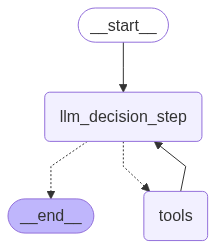

In [ ]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [65]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [66]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='af586f85-70c9-4d6f-bc06-5e8a60610c96'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zpz7seenz', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 308, 'prompt_tokens': 423, 'total_tokens': 731, 'completion_time': 1.12, 'prompt_time': 0.027128025, 'queue_time': 0.05424625499999999, 'total_time': 1.147128025}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4eb989b1-b7dc-4865-aa8a-38f2bed2cf43-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Narendra Modi age'}, 'id': 'zpz7seenz', 'type': 'tool_call'}], usage_metadata={'input_tokens': 423, 'output_tokens': 308, 'total_tokens': 731}),
  ToolMessage(content='Narendra M

In [73]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [74]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='How much is the net worth of Elon Musk, and divide it by 2?', additional_kwargs={}, response_metadata={}, id='ad33a1da-1bb4-4aaf-b9fb-77c9f7b8098b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4g6h57ezq', 'function': {'arguments': '{"query":"Elon Musk net worth 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 604, 'prompt_tokens': 427, 'total_tokens': 1031, 'completion_time': 2.21694758, 'prompt_time': 0.033785358, 'queue_time': 0.052339541, 'total_time': 2.250732938}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--01edde4b-f24c-403a-aa35-586631678509-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Elon Musk net worth 2023'}, 'id': '4g6h57ezq', 'type': 'tool_call'}], usage_metadata={'input_tokens': 427, 'output_tokens': 604, 'total_tokens': 1031})

In [77]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [78]:
response=react_graph.invoke({"messages":message})

In [79]:
response["messages"][-1].content

'The speed of light in meters per second is 299,792,000 m/s. When multiplied by 10, the result is 2,997,920,000 m/s. \n\n**Answer:** 2,997,920,000 m/s'

In [82]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (2eb9h3mkz)
 Call ID: 2eb9h3mkz
  Args:
    a: 299792000
    b: 10
================================= Tool Message =================================
Name: multiply

2997920000
================================== Ai Message ==================================

The speed of light in meters per second is 299,792,000 m/s. When multiplied by 10, the result is 2,997,920,000 m/s. 

**Answer:** 2,997,920,000 m/s


In [83]:
import yfinance as yf

In [ ]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"
     
    

In [86]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $199.20.'

In [87]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $319.11.'

In [88]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001F268978160>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001F246D88AF0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000001F268978280>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [89]:
tools = [add, multiply, divide, search,get_stock_price]

In [90]:
llm_with_tools=llm.bind_tools(tools)

In [91]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [93]:
response.content

''

In [94]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'ns7ma16fz',
  'type': 'tool_call'}]

In [95]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [96]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

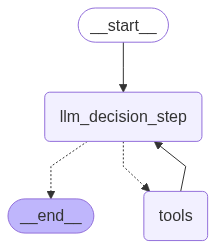

In [97]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [98]:
messages = [HumanMessage(content="add 1000 in the current stock price of Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [99]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 1000 in the current stock price of Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (hpxrhrp6w)
 Call ID: hpxrhrp6w
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $199.20.
================================== Ai Message ==================================

The result of adding 1000 to the current stock price of Apple is **$1199.20**.


In [104]:
messages = [HumanMessage(content="can you give me 2 times of current stock price of Apple with the latest news of the Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [105]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you give me 2 times of current stock price of Apple with the latest news of the Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (dkvyz3717)
 Call ID: dkvyz3717
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $199.20.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (44rn4a6n0)
 Call ID: 44rn4a6n0
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $199.20.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (w73514cxw)
 Call ID: w73514cxw
  Args:
    ticker: AAPL
===========================

In [ ]:
Assignment:
    
AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")

• Real-time weather information
• Top attractions and activities
• Hotel cost calculation (per day × total days)
• Currency conversion to user's native currency
• Complete itinerary generation
• Total expense calculation
• generate a summary of the entire output

user_input
  |
search attraction and activity
1. search attracation
2. search restaurant
3. search activity
4. search transportation
  |
search weather forcasting
1. get current weather
2. get weather forcast
  |
search hotel costs
1. search hotel
2. estimate the hotel cost
3. budget_range
  |
calculate total cost
1. add
2. multiply
3. calculated total cost
4. calcualte the daily budget
    | 
currency_converion
1. get exchnage rate
2. convert currancy
    | 
Itinery generation
1. get day plan
2. crete full itinery
    |
create Trip Summary
    |
Retun complete traval plan

Note: if you know the OOPS then design this entire system using object and class in modular fashion.


deadline is till next friday 9PM IST


 everyone you can submit the assignments in this form. MAke sure to have one GitHub link and put all the assignments there https://forms.gle/g8RZ4qx8yvNcih4B7    
    